# Classificação Multiclasse
## Previsão de Risco de Crédito (baixo / médio / alto)

Neste notebook, vamos construir um modelo para prever o **risco de crédito** de um cliente em três categorias:

- **baixo** — cliente seguro, baixo risco de inadimplência.
- **medio** — risco intermediário, exige atenção.
- **alto** — alto risco, candidato à recusa ou condições restritivas.

A diferença em relação à classificação binária é que agora a variável alvo tem **três classes** em vez de duas. Vamos usar a **regressão logística multinomial** (também chamada de *softmax regression*), que generaliza a regressão logística:

$$P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \quad z_k = b_{0,k} + b_{1,k} x_1 + \dots + b_{n,k} x_n$$

Em vez de um único conjunto de coeficientes, o modelo aprende **um conjunto por classe** e escolhe a classe com maior probabilidade.

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
)

sns.set_style('whitegrid')

## 2. Carregamento dos Dados

O dataset tem 600 clientes com seis variáveis explicativas e a classificação de risco atribuída pelo banco.

- `renda_mensal` — renda mensal (R\$)
- `score_credito` — pontuação de crédito (300 a 850)
- `divida_atual` — dívida total atual (R\$)
- `idade` — idade (anos)
- `tempo_emprego_anos` — tempo no emprego atual
- `num_dependentes` — número de dependentes
- `risco_credito` — **alvo**: `baixo`, `medio` ou `alto`

In [2]:
df = pd.read_csv('dados_risco_credito.csv')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head(10)

Dimensões: 600 linhas × 7 colunas


,renda_mensal,score_credito,divida_atual,idade,tempo_emprego_anos,num_dependentes,risco_credito
0,4803.12,570,22747.50,68,0.6,4,alto
1,26725.15,317,38926.49,55,4.7,2,medio
2,15444.06,356,58074.40,21,20.0,5,alto
3,5536.71,379,3456.06,48,18.9,3,medio
4,5851.67,554,55371.86,57,28.1,3,alto
5,21094.72,638,34068.68,44,23.9,5,baixo
6,2850.12,742,42263.81,41,17.0,2,alto
7,9667.92,428,8951.05,60,4.1,2,medio
8,5483.95,733,32003.25,50,16.9,2,medio
9,14070.71,666,40410.82,54,1.8,5,alto


In [3]:
df.describe().round(2)

,renda_mensal,score_credito,divida_atual,idade,tempo_emprego_anos,num_dependentes
count,600.00,600.00,600.00,600.00,600.00,600.00
mean,15339.64,571.64,29457.05,44.75,14.71,2.54
std,8286.47,153.68,17639.12,14.20,8.57,1.73
min,1610.98,300.00,38.54,20.00,0.10,0.00
25%,8497.11,437.00,14539.73,32.00,7.10,1.00
50%,15300.00,572.50,30373.46,45.00,14.90,2.00
75%,22322.82,707.00,44140.53,57.00,21.70,4.00
max,29993.31,850.00,59964.54,69.00,30.00,5.00


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   renda_mensal        600 non-null    float64
 1   score_credito       600 non-null    int64  
 2   divida_atual        600 non-null    float64
 3   idade               600 non-null    int64  
 4   tempo_emprego_anos  600 non-null    float64
 5   num_dependentes     600 non-null    int64  
 6   risco_credito       600 non-null    str    
dtypes: float64(3), int64(3), str(1)
memory usage: 32.9 KB


## 3. Análise Exploratória

### 3.1 Distribuição das Classes

Distribuição da variável alvo:
  baixo : 204 amostras (34.0%)
  alto  : 198 amostras (33.0%)
  medio : 198 amostras (33.0%)


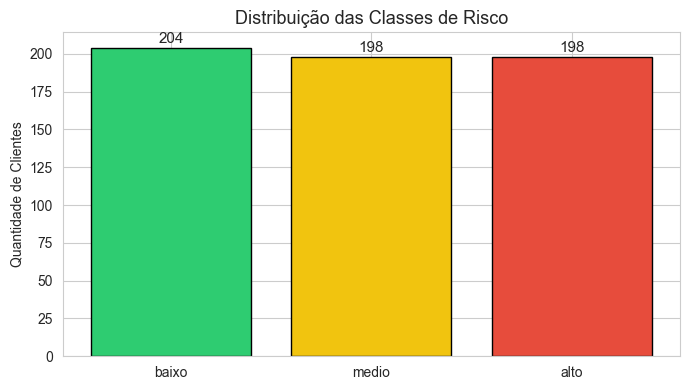

In [5]:
contagem = df['risco_credito'].value_counts()
proporcao = df['risco_credito'].value_counts(normalize=True)

print('Distribuição da variável alvo:')
for classe, qtd in contagem.items():
    print(f'  {classe:<6s}: {qtd} amostras ({proporcao[classe]:.1%})')

cores_mapa = {'baixo': '#2ecc71', 'medio': '#f1c40f', 'alto': '#e74c3c'}
ordem = ['baixo', 'medio', 'alto']

plt.figure(figsize=(7, 4))
plt.bar(ordem, [contagem[c] for c in ordem],
        color=[cores_mapa[c] for c in ordem], edgecolor='black')
plt.title('Distribuição das Classes de Risco', fontsize=13)
plt.ylabel('Quantidade de Clientes')
for i, c in enumerate(ordem):
    plt.text(i, contagem[c] + 3, str(contagem[c]), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 3.2 Variáveis Numéricas por Classe

Um boxplot por classe nos mostra como cada variável se comporta em cada nível de risco. Diferenças entre as caixas sugerem que aquela variável ajuda a separar as classes.

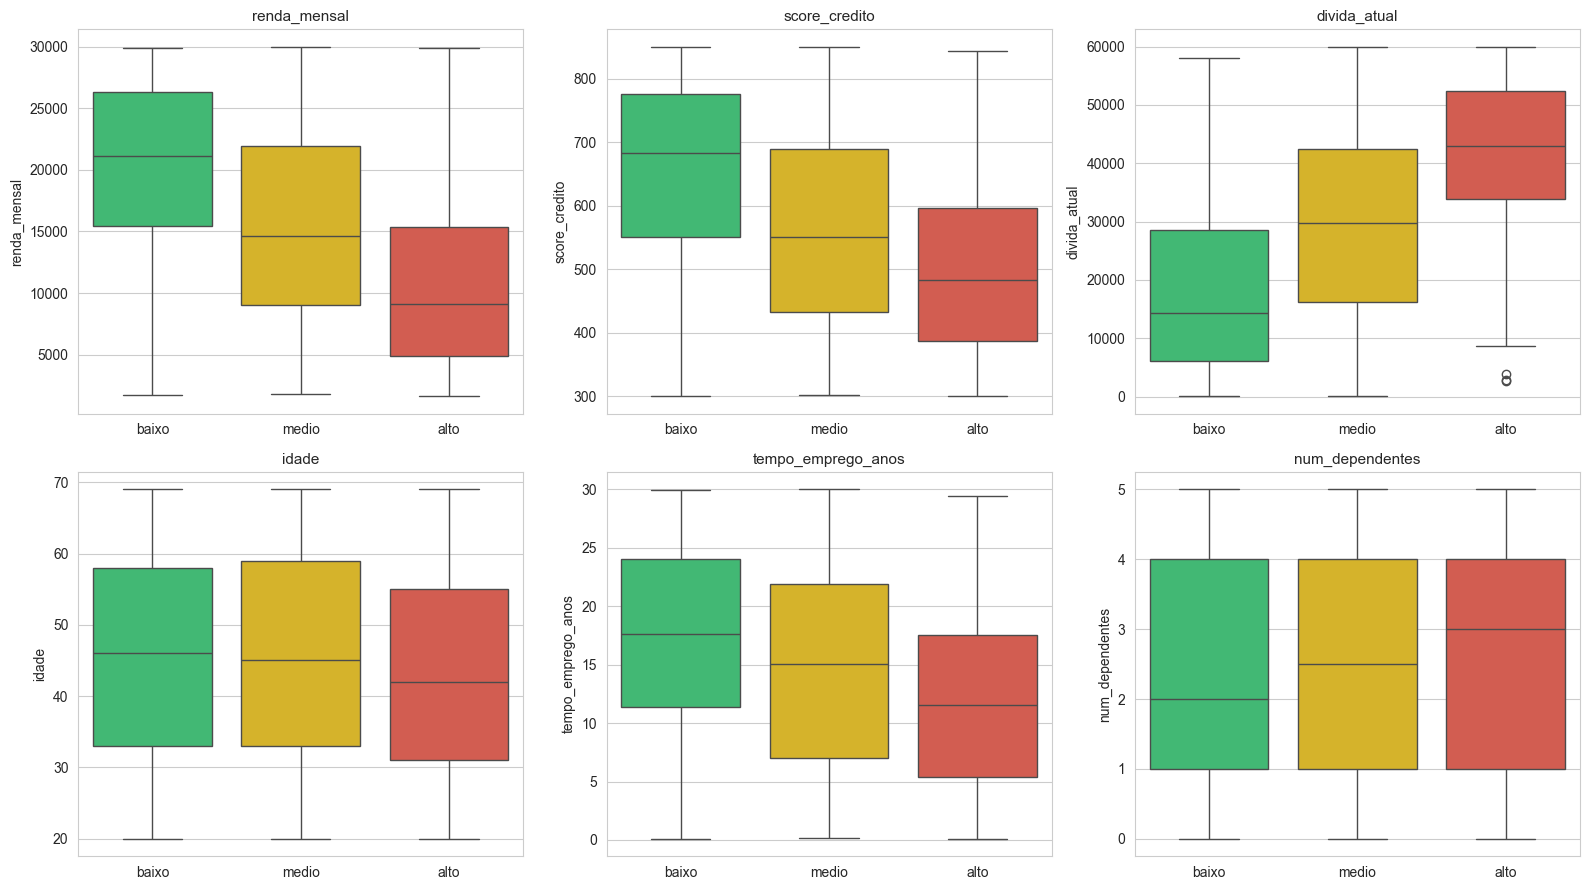

In [6]:
variaveis = ['renda_mensal', 'score_credito', 'divida_atual',
             'idade', 'tempo_emprego_anos', 'num_dependentes']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

ordem = ['baixo', 'medio', 'alto']
paleta = ['#2ecc71', '#f1c40f', '#e74c3c']

for i, col in enumerate(variaveis):
    sns.boxplot(data=df, x='risco_credito', y=col,
                order=ordem, hue='risco_credito', hue_order=ordem,
                palette=paleta, legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 3.3 Matriz de Correlação (variáveis numéricas)

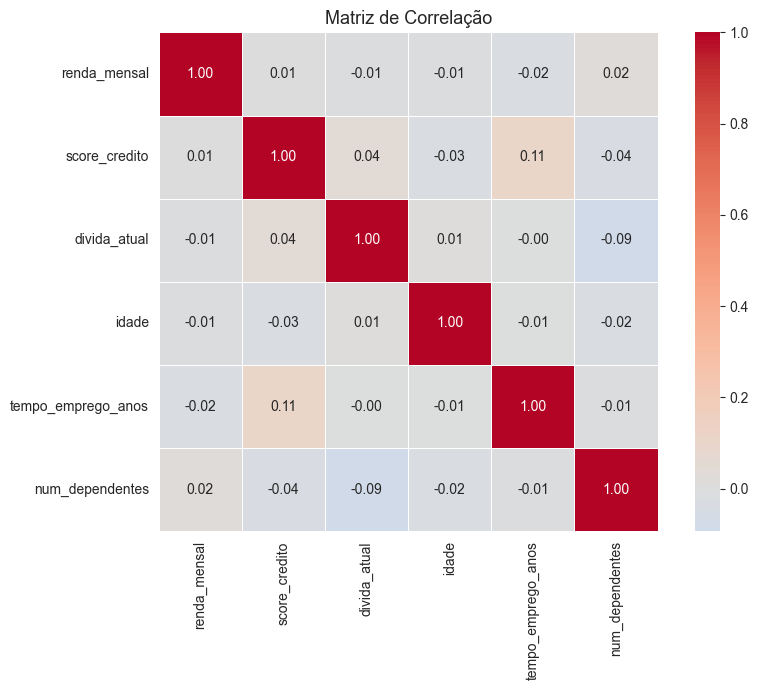

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.drop(columns='risco_credito').corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preparação dos Dados

Para classificação multiclasse com regressão logística precisamos:

1. **Codificar a variável alvo** com `LabelEncoder` (transformar texto em número).
2. **Dividir** em treino e teste (estratificado, para preservar a proporção das classes).
3. **Padronizar** as features.

In [8]:
le = LabelEncoder()
y = le.fit_transform(df['risco_credito'])

print('Mapeamento das classes:')
for i, classe in enumerate(le.classes_):
    print(f'  {classe} → {i}')

X = df.drop(columns='risco_credito')

Mapeamento das classes:
  alto → 0
  baixo → 1
  medio → 2


In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Treino: 480 amostras
Teste:  120 amostras


## 5. Treinamento do Modelo

A `LogisticRegression` do scikit-learn detecta automaticamente que temos mais de duas classes e usa o esquema **multinomial** — uma única função softmax sobre todas as classes (mais eficiente que treinar um modelo por classe).

In [10]:
modelo = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
modelo.fit(X_treino_scaled, y_treino)

print(f'Classes: {le.classes_}')
print(f'\nFormato dos coeficientes: {modelo.coef_.shape}')
print('  (uma linha por classe, uma coluna por feature)')

Classes: ['alto' 'baixo' 'medio']

Formato dos coeficientes: (3, 6)
  (uma linha por classe, uma coluna por feature)


## 6. Coeficientes — Como Cada Variável Influencia Cada Classe

Como temos 3 classes, temos **3 conjuntos de coeficientes**. Para cada classe, um coeficiente positivo de uma variável significa "essa variável aumenta a probabilidade desta classe específica".

In [11]:
coef_df = pd.DataFrame(
    modelo.coef_,
    columns=X.columns,
    index=le.classes_
)
print('Coeficientes (linhas = classes, colunas = features):\n')
print(coef_df.round(3))

Coeficientes (linhas = classes, colunas = features):

       renda_mensal  score_credito  divida_atual  idade  tempo_emprego_anos  \
alto         -2.868         -2.339         3.426 -0.564              -1.205   
baixo         2.872          2.393        -3.400  0.529               1.139   
medio        -0.004         -0.054        -0.026  0.036               0.066   

       num_dependentes  
alto             0.850  
baixo           -0.971  
medio            0.120  


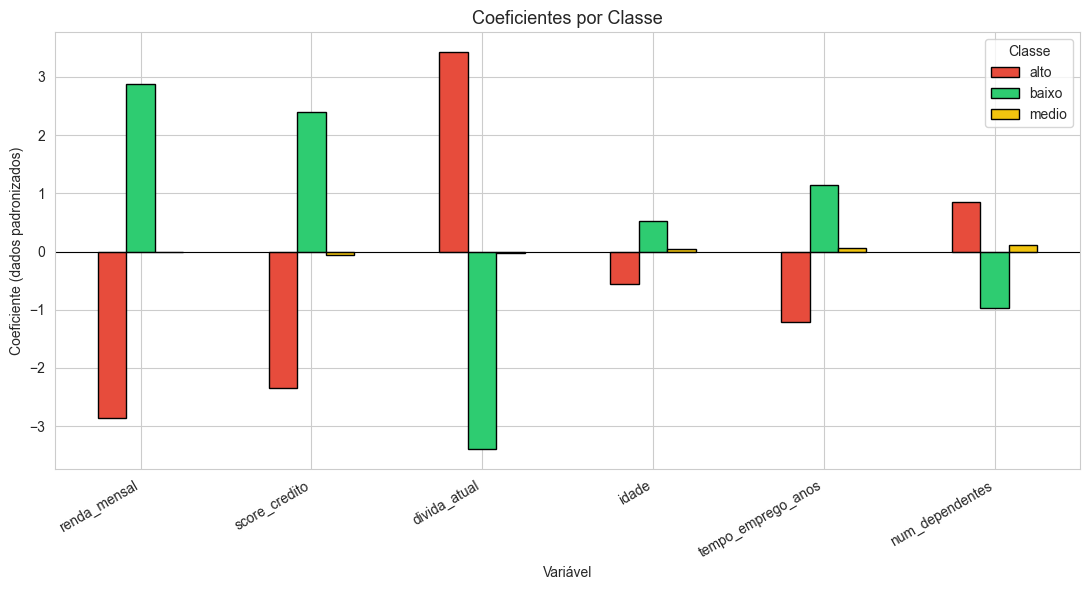

In [12]:
plt.figure(figsize=(11, 6))
coef_df.T.plot(kind='bar', figsize=(11, 6),
               color=['#e74c3c', '#2ecc71', '#f1c40f'],
               edgecolor='black', ax=plt.gca())
plt.title('Coeficientes por Classe', fontsize=13)
plt.ylabel('Coeficiente (dados padronizados)')
plt.xlabel('Variável')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Classe', loc='best')
plt.tight_layout()
plt.show()

**Como ler:**
Para a classe `alto`, coeficientes negativos em `score_credito` ou `renda_mensal` indicam que clientes com alto score / alta renda têm baixa probabilidade de cair na classe "alto risco" — exatamente o que esperamos.

## 7. Previsões no Conjunto de Teste

In [13]:
y_pred = modelo.predict(X_teste_scaled)
y_proba = modelo.predict_proba(X_teste_scaled)

resultado = pd.DataFrame({
    'Real': le.inverse_transform(y_teste),
    'Previsto': le.inverse_transform(y_pred),
    'Prob. baixo': y_proba[:, 1].round(3),
    'Prob. medio': y_proba[:, 2].round(3),
    'Prob. alto':  y_proba[:, 0].round(3),
})
resultado.head(10)

,Real,Previsto,Prob. baixo,Prob. medio,Prob. alto
0,alto,medio,0.014,0.723,0.263
1,medio,medio,0.063,0.804,0.133
2,medio,medio,0.157,0.795,0.048
3,medio,medio,0.467,0.528,0.005
4,baixo,baixo,0.931,0.069,0.000
5,alto,alto,0.000,0.113,0.887
6,medio,medio,0.410,0.583,0.007
7,medio,medio,0.184,0.798,0.018
8,medio,medio,0.169,0.804,0.027
9,baixo,baixo,0.747,0.253,0.001


## 8. Avaliação do Modelo

### 8.1 Métricas Globais

Em problemas multiclasse, geralmente reportamos:

- **Acurácia geral**.
- **Métricas por classe** (precisão, recall, F1).
- **Médias agregadas**:
  - **Macro**: média simples entre as classes — trata todas igualmente.
  - **Weighted**: média ponderada pela quantidade de amostras de cada classe.

In [14]:
acc = accuracy_score(y_teste, y_pred)
print(f'Acurácia geral: {acc:.4f}\n')
print('--- classification_report ---')
print(classification_report(y_teste, y_pred, target_names=le.classes_))

Acurácia geral: 0.8417

--- classification_report ---
              precision    recall  f1-score   support

        alto       0.91      0.78      0.84        40
       baixo       0.95      0.88      0.91        41
       medio       0.71      0.87      0.78        39

    accuracy                           0.84       120
   macro avg       0.86      0.84      0.84       120
weighted avg       0.86      0.84      0.84       120



### 8.2 Matriz de Confusão Multiclasse

A matriz agora é 3×3. As células fora da diagonal mostram **onde o modelo confunde as classes**.

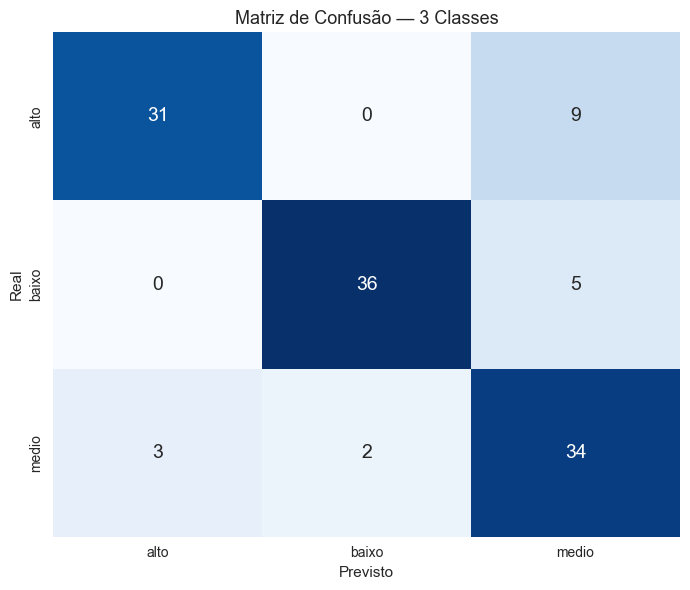

In [15]:
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, annot_kws={'size': 14})
plt.xlabel('Previsto', fontsize=11)
plt.ylabel('Real', fontsize=11)
plt.title('Matriz de Confusão — 3 Classes', fontsize=13)
plt.tight_layout()
plt.show()

**Insights típicos da matriz multiclasse:**

- A **diagonal principal** = acertos. Quanto mais "concentrada" na diagonal, melhor.
- Erros entre classes **adjacentes** (`baixo` ↔ `medio`, `medio` ↔ `alto`) costumam ser mais comuns — e menos graves — do que erros entre classes extremas (`baixo` ↔ `alto`).

## 9. Análise de Erros

Vamos olhar alguns exemplos onde o modelo errou para entender o que pode estar acontecendo.

In [16]:
erros_idx = np.where(y_teste != y_pred)[0]
print(f'O modelo errou em {len(erros_idx)} de {len(y_teste)} amostras de teste '
      f'({len(erros_idx)/len(y_teste):.1%}).\n')

# Mostra alguns erros com as probabilidades atribuídas a cada classe
amostras_erro = pd.DataFrame(X_teste.iloc[erros_idx].values, columns=X.columns)
amostras_erro['Real'] = le.inverse_transform(y_teste[erros_idx])
amostras_erro['Previsto'] = le.inverse_transform(y_pred[erros_idx])
amostras_erro.head(10).round(2)

O modelo errou em 19 de 120 amostras de teste (15.8%).



,renda_mensal,score_credito,divida_atual,idade,tempo_emprego_anos,num_dependentes,Real,Previsto
0,27529.57,531.0,48981.42,33.0,13.2,4.0,alto,medio
1,17848.76,578.0,38885.64,36.0,24.0,5.0,alto,medio
2,10752.34,786.0,25002.25,35.0,2.9,1.0,baixo,medio
3,26725.15,317.0,38926.49,55.0,4.7,2.0,medio,alto
4,7268.55,784.0,9456.09,27.0,14.3,5.0,baixo,medio
5,25103.64,722.0,56648.74,40.0,29.3,2.0,medio,baixo
6,8547.11,365.0,2841.83,23.0,22.5,4.0,alto,medio
7,25331.69,640.0,42314.40,21.0,9.6,4.0,alto,medio
8,5656.22,839.0,37201.89,27.0,28.0,1.0,baixo,medio
9,19501.41,587.0,30388.40,39.0,16.7,3.0,baixo,medio


## 10. Fazendo Novas Previsões

In [17]:
novos_clientes = pd.DataFrame({
    'renda_mensal':       [4500,   12000,  20000,  28000,  3000],
    'score_credito':      [400,    600,    750,    820,    330],
    'divida_atual':       [25000,  18000,  8000,   2000,   45000],
    'idade':              [28,     40,     50,     55,     35],
    'tempo_emprego_anos': [2.0,    10.0,   18.0,   25.0,   1.5],
    'num_dependentes':    [3,      2,      1,      0,      4],
})

novos_scaled = scaler.transform(novos_clientes)
previsoes = modelo.predict(novos_scaled)
probabilidades = modelo.predict_proba(novos_scaled)

for i, (_, c) in enumerate(novos_clientes.iterrows()):
    classe = le.inverse_transform([previsoes[i]])[0]
    probs = {cl: f'{p:.1%}' for cl, p in zip(le.classes_, probabilidades[i])}
    print(f'Cliente {i+1}: renda R$ {c.renda_mensal:>5,.0f} | '
          f'score {c.score_credito:>3.0f} | '
          f'dívida R$ {c.divida_atual:>5,.0f}')
    print(f'   → Risco previsto: {classe.upper()}')
    print(f'   → Probabilidades: {probs}\n')

Cliente 1: renda R$ 4,500 | score 400 | dívida R$ 25,000
   → Risco previsto: ALTO
   → Probabilidades: {'alto': '99.7%', 'baixo': '0.0%', 'medio': '0.3%'}

Cliente 2: renda R$ 12,000 | score 600 | dívida R$ 18,000
   → Risco previsto: MEDIO
   → Probabilidades: {'alto': '2.6%', 'baixo': '22.0%', 'medio': '75.5%'}

Cliente 3: renda R$ 20,000 | score 750 | dívida R$ 8,000
   → Risco previsto: BAIXO
   → Probabilidades: {'alto': '0.0%', 'baixo': '100.0%', 'medio': '0.0%'}

Cliente 4: renda R$ 28,000 | score 820 | dívida R$ 2,000
   → Risco previsto: BAIXO
   → Probabilidades: {'alto': '0.0%', 'baixo': '100.0%', 'medio': '0.0%'}

Cliente 5: renda R$ 3,000 | score 330 | dívida R$ 45,000
   → Risco previsto: ALTO
   → Probabilidades: {'alto': '100.0%', 'baixo': '0.0%', 'medio': '0.0%'}



---

## Conclusão

A classificação multiclasse expande naturalmente a binária:

- A função sigmoide vira **softmax**, que distribui probabilidade entre todas as classes.
- Cada classe ganha seu próprio conjunto de coeficientes.
- A avaliação inclui métricas **por classe** + médias macro/weighted.
- A matriz de confusão fica maior (K × K) e revela **quais classes o modelo confunde**.

No próximo notebook, vamos manter o mesmo problema (risco de crédito) e comparar **três algoritmos diferentes** — Decision Tree, Random Forest e XGBoost — para entender suas forças e fraquezas.